# Classification

### Section A — Dataset & Exploratory Data Analysis (EDA)

This section introduces the Mushroom dataset and explores its structure, data quality, feature distributions, target distribution, and relationships between the features and the target variable.

### A1 — Dataset Loading & Audit

The Mushroom dataset is loaded and examined to understand its structure and data quality. The dataset contains categorical characteristics of mushrooms, with the `class` variable representing whether a mushroom is edible or poisonous.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the Dataset

The `agaricus-lepiota.data` file contains the actual mushroom observations. Since the original file does not contain column headers, it is loaded without a header.

In [48]:
df = pd.read_csv("agaricus-lepiota.data", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Assigning Column Names

The dataset contains 23 variables, including one target variable and 22 predictor features. The appropriate feature names are assigned to make the dataset easier to interpret and analyse.

In [50]:
columns = [
    'class',
    'cap-shape',
    'cap-surface',
    'cap-color',
    'bruises',
    'odor',
    'gill-attachment',
    'gill-spacing',
    'gill-size',
    'gill-color',
    'stalk-shape',
    'stalk-root',
    'stalk-surface-above-ring',
    'stalk-surface-below-ring',
    'stalk-color-above-ring',
    'stalk-color-below-ring',
    'veil-type',
    'veil-color',
    'ring-number',
    'ring-type',
    'spore-print-color',
    'population',
    'habitat'
]

df.columns = columns

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Dataset Dimensions

The dimensions of the dataset are examined to determine the number of observations and variables available for analysis.

In [51]:
print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (8124, 23)
Number of Rows: 8124
Number of Columns: 23


### Data Types

The data type of each variable is examined to understand how the features are stored. The mushroom characteristics are categorical and are therefore stored as object values in the original dataset.

In [52]:
print("Data Types:")
print(df.dtypes)

Data Types:
class                       object
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-root                  object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
dtype: object


### Missing-Value Audit

The original Mushroom dataset uses the symbol `?` to represent missing values. The number of such entries in each column is calculated to identify variables that may require treatment during preprocessing.

In [53]:
missing_values = (df == '?').sum()

print("Missing-value counts:")
print(missing_values)

Missing-value counts:
class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64


### Target/Class Distribution

The `class` variable is the target variable. The values `e` and `p` represent edible and poisonous mushrooms respectively. The class distribution is examined to understand how the target classes are represented in the dataset.

In [54]:
print("Target/Class Distribution:")
print(df['class'].value_counts())

Target/Class Distribution:
class
e    4208
p    3916
Name: count, dtype: int64


In [55]:
print("\nTarget/Class Distribution (%):")
print((df['class'].value_counts(normalize=True) * 100).round(2))


Target/Class Distribution (%):
class
e    51.8
p    48.2
Name: proportion, dtype: float64


### A1 - Audit Summary

The dataset contains 8,124 observations and 23 variables, including one target variable and 22 predictor features. The predictor variables are categorical in nature. Missing values are represented by `?` in the original dataset and are mainly present in the `stalk-root` feature. The target variable consists of two classes: edible (`e`) and poisonous (`p`).

## A2 — Exploratory Data Analysis Visualisations

Visualisations are used to understand the distribution of the mushroom features and to identify relationships between the features and the target variable. Since the features are categorical, count plots are used to display their distributions.

### Distribution of Features

The distribution of each predictor feature is visualised using count plots. These plots show how frequently each category occurs within a feature and help identify dominant and less frequent categories.

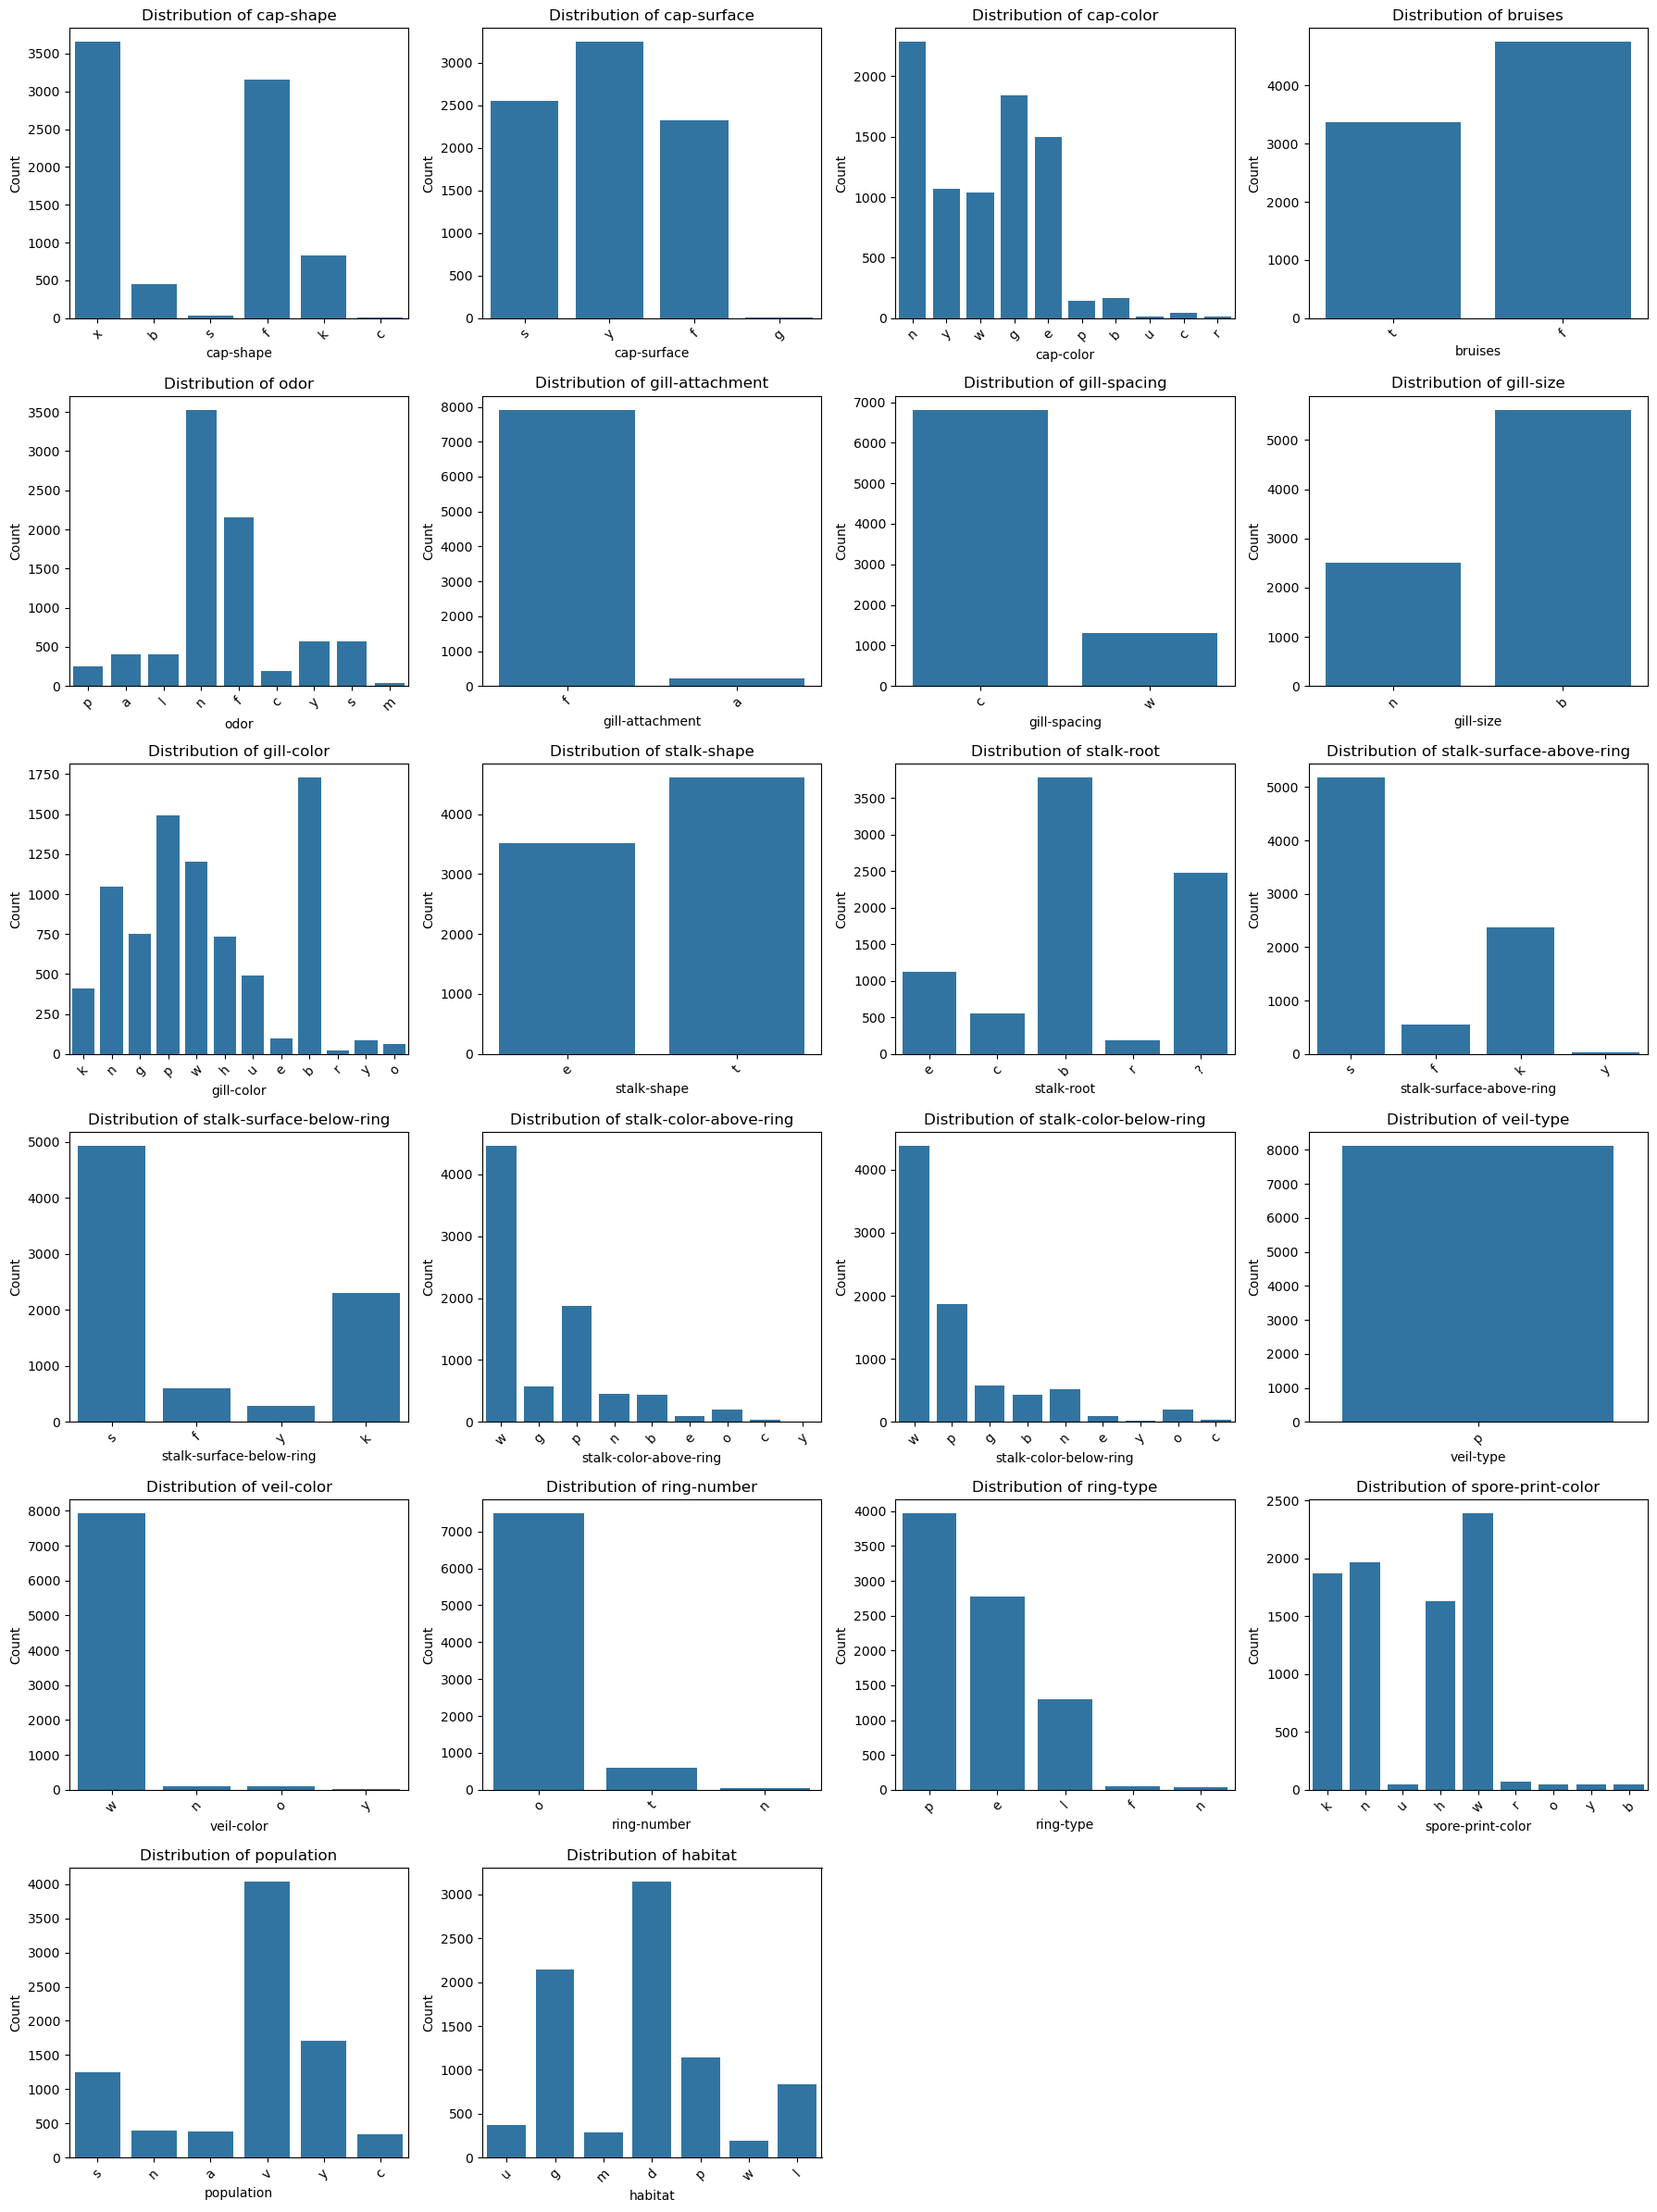

In [56]:
features = df.columns[1:]

fig, axes = plt.subplots(6, 4, figsize=(18, 24))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.countplot(data=df, x=feature, ax=axes[i])
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

for i in range(len(features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## A3 — Observation: Feature Distributions

The feature distributions show that the categories are not equally represented across the variables. Some categories occur more frequently than others, while some are relatively rare. This indicates variation in the distribution of the different mushroom characteristics.

### Target Distribution

The target variable is visualised separately to clearly compare the number of edible and poisonous mushrooms in the dataset.

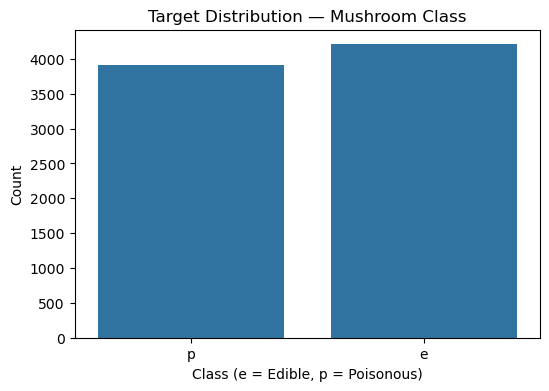

In [57]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='class')

plt.title("Target Distribution — Mushroom Class")
plt.xlabel("Class (e = Edible, p = Poisonous)")
plt.ylabel("Count")

plt.show()

## A3 — Observation: Target Distribution

The target variable contains two classes, edible (`e`) and poisonous (`p`). Both classes are well represented in the dataset, although their frequencies are not equal. The class distribution should therefore be considered when splitting the data for model training and evaluation.

### Correlation Heatmap

A correlation heatmap is created to explore the associations between the encoded categorical variables and the target. The categorical values are temporarily converted to numerical codes only for this exploratory visualisation.

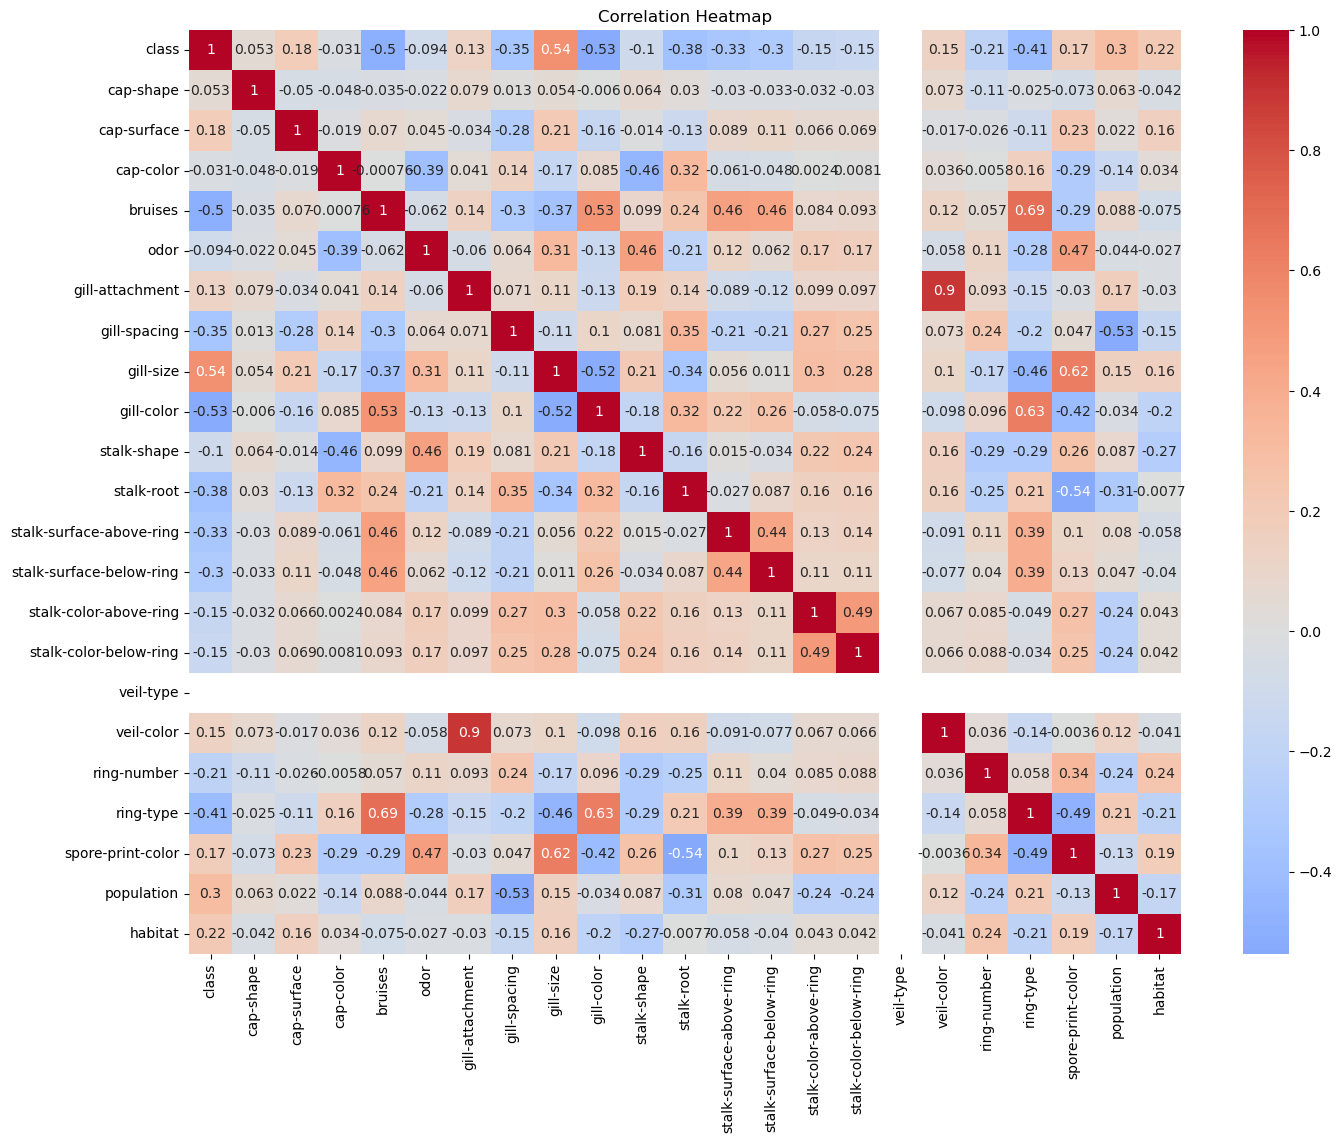

In [60]:
df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

plt.figure(figsize=(16, 12))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

## A3 — Observation: Correlation Heatmap

The heatmap shows that the features have different levels of association with the target variable. Some features show stronger associations with mushroom class than others, suggesting that they may provide useful information for classification. Since the original variables are categorical, these correlations are interpreted as exploratory associations.

### Feature–Target Relationship: Odor

A scatter plot is used to examine the relationship between the `odor` feature and the mushroom class. The categorical values are numerically encoded only to allow them to be represented on a scatter plot.

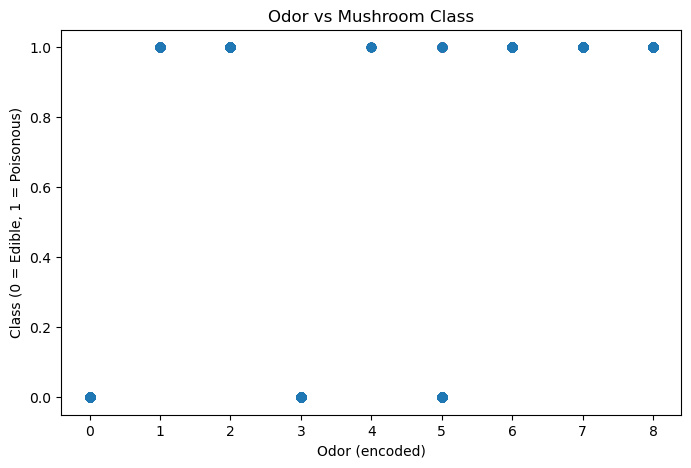

In [61]:
scatter_df = df.copy()

scatter_df['class_num'] = scatter_df['class'].map({
    'e': 0,
    'p': 1
})

scatter_df['odor_num'] = (
    scatter_df['odor'].astype('category').cat.codes
)

plt.figure(figsize=(8, 5))

plt.scatter(
    scatter_df['odor_num'],
    scatter_df['class_num'],
    alpha=0.3
)

plt.xlabel("Odor (encoded)")
plt.ylabel("Class (0 = Edible, 1 = Poisonous)")
plt.title("Odor vs Mushroom Class")

plt.show()

## A3 — Observation: Odor vs Mushroom Class

The distribution of edible and poisonous mushrooms varies across the odor categories. Certain odor categories are more strongly associated with one class than the other, indicating that odor may provide useful information for distinguishing between edible and poisonous mushrooms.

### Feature–Target Relationship: Gill Size

A second scatter plot is used to examine the relationship between `gill-size` and the mushroom class. The categorical values of gill size are temporarily encoded numerically for visualisation.

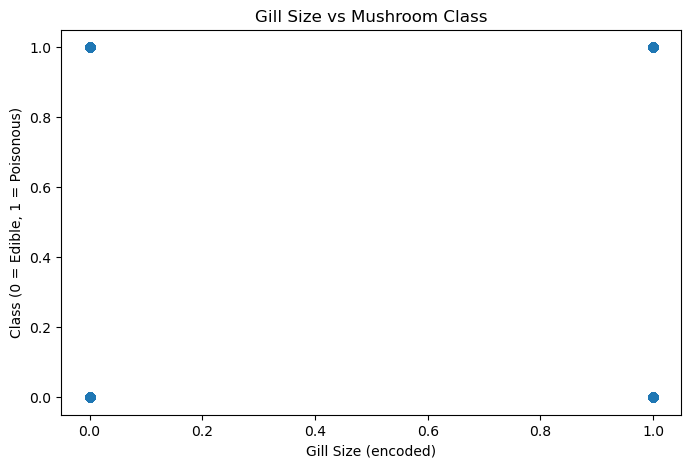

In [62]:
scatter_df['gill_size_num'] = (
    scatter_df['gill-size'].astype('category').cat.codes
)

plt.figure(figsize=(8, 5))

plt.scatter(
    scatter_df['gill_size_num'],
    scatter_df['class_num'],
    alpha=0.3
)

plt.xlabel("Gill Size (encoded)")
plt.ylabel("Class (0 = Edible, 1 = Poisonous)")
plt.title("Gill Size vs Mushroom Class")

plt.show()

## A3 — Observation: Gill Size vs Mushroom Class

The distribution of edible and poisonous mushrooms differs across the gill-size categories. This suggests that gill size contains information related to the target variable and may contribute to the classification of mushrooms.

## Section A — Summary

The exploratory analysis provides an overview of the Mushroom dataset, including its dimensions, data types, missing values, class distribution, feature distributions, and feature-target relationships. The visualisations indicate that several mushroom characteristics show differences across the edible and poisonous classes. These observations provide a basis for the preprocessing and classification steps in the following sections.

# Section B — Preprocessing & Feature Engineering

This section prepares the Mushroom dataset for classification. The data is cleaned by handling missing values and checking duplicates, while categorical features are encoded and the data is split into training and testing sets. An additional feature is also created to provide potentially useful information for classification.

## B1 — Data Cleaning

The dataset is checked for missing values, duplicate records, and potential outliers. Since the Mushroom dataset contains categorical features, the cleaning strategy is selected based on the nature of the data.

### Handling Missing Values

In the original dataset, missing values are represented by `?`. These values are converted to missing values and replaced using the mode of the corresponding categorical feature. The mode is appropriate because the affected variables are categorical.

In [63]:
# Replace '?' with NaN
df = df.replace('?', np.nan)

# Check missing values
print("Missing values before treatment:")
print(df.isnull().sum())

Missing values before treatment:
class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64


In [64]:
# Fill missing categorical values with the mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


### Checking Duplicate Records

Duplicate records are checked because repeated observations can affect the analysis and may cause the model to give excessive importance to identical samples. Any duplicate rows found are removed before model training.

In [65]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [66]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (8124, 23)


### Outlier Check

The predictor variables in the Mushroom dataset are categorical rather than continuous numerical measurements. Therefore, numerical outlier techniques such as the IQR method are not appropriate for the original features. Category frequencies were examined during EDA, and no numerical outlier removal was applied.

## B3 — Feature Engineering

Definition : Feature engineering means creating new useful features (columns) from the existing data so that a machine-learning model can learn patterns more easily.
A new feature is created by comparing the stalk color above and below the ring. This feature indicates whether the two stalk-color measurements are the same and combines information from two related variables into a single indicator.

In [67]:
df['stalk-color-match'] = (
    df['stalk-color-above-ring'] ==
    df['stalk-color-below-ring']
).astype(int)

df[['stalk-color-above-ring',
    'stalk-color-below-ring',
    'stalk-color-match']].head()

,stalk-color-above-ring,stalk-color-below-ring,stalk-color-match
0,w,w,1
1,w,w,1
2,w,w,1
3,w,w,1
4,w,w,1


### Feature Engineering Justification

The `stalk-color-match` feature has two possible values: 1 when the stalk color above and below the ring is the same, and 0 when they are different. This engineered feature may help the classification models identify patterns involving stalk characteristics more easily than using the two related features independently.

## B2 — Encoding, Scaling & Splitting

The target variable is separated from the predictor features. The categorical predictor variables are encoded using one-hot encoding. The data is then divided into training and testing sets using stratified sampling so that the class proportions are maintained.

### Separating Features and Target

The `class` column is used as the target variable, while the remaining columns are used as predictor features. The target values are encoded as 0 for edible mushrooms and 1 for poisonous mushrooms.

In [68]:
X = df.drop('class', axis=1)

y = df['class'].map({
    'e': 0,
    'p': 1
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (8124, 23)
Target shape: (8124,)


### Stratified Train-Test Split

The dataset is divided into training and testing sets using an 80:20 split. Stratification is applied to preserve the proportion of edible and poisonous mushrooms in both sets.

In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (6499, 23)
Testing set: (1625, 23)


### Encoding and Scaling

The predictor variables are categorical, so one-hot encoding is used to convert them into numerical features. Standard scaling is applied to the numerical engineered feature. The preprocessing steps are placed inside a pipeline so that they are fitted only on the training data, preventing data leakage.

In [70]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_features = X_train.select_dtypes(
    include='object'
).columns

numerical_features = X_train.select_dtypes(
    exclude='object'
).columns

preprocessor = ColumnTransformer(
    # Encoding categorical features
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            categorical_features
        ),
        # Scaling numerical features
        (
            'numerical',
            StandardScaler(),
            numerical_features
        )
    ]
)

### Applying the Preprocessing Pipeline

The preprocessing steps are combined into a pipeline and fitted using only the training data. The same fitted preprocessing is then applied to the testing data without refitting, which prevents data leakage.

In [71]:
from sklearn.pipeline import Pipeline
# Apply encoding and scaling to the training and testing data
preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])
# Fit preprocessing on training data and transform it
X_train_processed = preprocessing_pipeline.fit_transform(X_train)

# Transform test data using the already fitted preprocessing
X_test_processed = preprocessing_pipeline.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (6499, 117)
Processed testing shape: (1625, 117)


### Preprocessing Summary

The categorical features have been converted into numerical features using one-hot encoding, while the numerical features have been standardised using StandardScaler. The preprocessing pipeline was fitted only on the training data and then applied to the testing data, ensuring that information from the test set was not used during preprocessing.

# Section D — Classification Track, Part A

In this section, five classification algorithms are trained and evaluated on the preprocessed Mushroom dataset. The algorithms are Logistic Regression, K-Nearest Neighbors, Gaussian Naive Bayes, Decision Tree Classifier, and Support Vector Machine.

Each model is evaluated using accuracy, weighted F1-score, and a confusion matrix.

## D1 — Implementation

The five Part-A classification algorithms are trained using the preprocessed training data. Predictions are generated on the unseen test data for each algorithm.

### Logistic Regression

Logistic Regression is used as a linear classification model. It provides a baseline for predicting whether a mushroom is edible or poisonous.

In [72]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

y_pred_lr = logistic_model.predict(X_test_processed)

print("Logistic Regression predictions generated successfully.")

Logistic Regression predictions generated successfully.


### Logistic Regression — Coefficient Interpretation

The coefficients of Logistic Regression indicate the direction and strength of the relationship between the encoded features and the predicted class. Positive coefficients increase the tendency toward the poisonous class, while negative coefficients indicate a tendency toward the edible class.

The exponentiated coefficient represents the corresponding change in odds for a one-unit increase in the encoded feature.

In [73]:
# Get feature names after one-hot encoding
feature_names = preprocessing_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

coefficients = logistic_model.coef_[0]

coefficient_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds_Ratio': np.exp(coefficients)
})

coefficient_df['Absolute_Coefficient'] = (
    coefficient_df['Coefficient'].abs()
)

coefficient_df.sort_values(
    'Absolute_Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient,Odds_Ratio,Absolute_Coefficient
27,categorical__odor_n,-4.315744,0.013357,4.315744
99,categorical__spore-print-color_r,3.888343,48.829902,3.888343
24,categorical__odor_f,3.167450,23.746863,3.167450
23,categorical__odor_c,3.013780,20.364237,3.013780
25,categorical__odor_l,-2.829483,0.059043,2.829483
22,categorical__odor_a,-2.785821,0.061678,2.785821
36,categorical__gill-size_n,2.115544,8.294097,2.115544
35,categorical__gill-size_b,-2.072851,0.125827,2.072851
90,categorical__ring-type_f,-2.038253,0.130256,2.038253
28,categorical__odor_p,1.959940,7.098898,1.959940


### Observation

The coefficient table shows the encoded features that have the strongest influence on the Logistic Regression predictions. Positive coefficients are associated with higher predicted odds of the poisonous class, while negative coefficients are associated with higher predicted odds of the edible class.

## K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) classifies a mushroom based on the classes of the nearest observations in the feature space. The value of `k` determines how many neighboring observations are considered for classification.

Different values of `k` are tested to identify a suitable number of neighbors. Euclidean distance is used as the distance metric because the categorical features have been converted into numerical features through one-hot encoding.

In [74]:
# Tune k
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Values of k to compare
k_values = [3, 5, 7, 9, 11]

knn_tuning_results = []

for k in k_values:
    
    knn_model_temp = KNeighborsClassifier(
        n_neighbors=k,
        metric='euclidean'
    )
    
    # Train the model
    knn_model_temp.fit(X_train_processed, y_train)
    
    # Generate predictions
    y_pred_knn_temp = knn_model_temp.predict(X_test_processed)
    
    # Calculate accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred_knn_temp
    )
    
    knn_tuning_results.append({
        'k': k,
        'Accuracy': accuracy
    })

knn_tuning_df = pd.DataFrame(knn_tuning_results)

knn_tuning_df

,k,Accuracy
0,3,1.000000
1,5,1.000000
2,7,1.000000
3,9,1.000000
4,11,0.998769


### Selecting the Number of Neighbors

The value of `k` with the highest classification accuracy is selected as the final KNN configuration.

In [75]:
best_k = knn_tuning_df.loc[
    knn_tuning_df['Accuracy'].idxmax(),
    'k'
]

print("Selected k:", best_k)

Selected k: 3


### Final KNN Model

The KNN model is trained again using the selected value of `k`. The final model is then used to generate predictions on the test dataset.

In [76]:
knn_model = KNeighborsClassifier(
    n_neighbors=int(best_k),
    metric='euclidean'
)

knn_model.fit(
    X_train_processed,
    y_train
)

y_pred_knn = knn_model.predict(
    X_test_processed
)

print("KNN predictions generated successfully.")

KNN predictions generated successfully.


### KNN — Distance Metric

Euclidean distance measures the distance between observations in the transformed numerical feature space. Since the categorical variables have been converted into numerical one-hot encoded features, Euclidean distance can be used to identify nearby observations for KNN classification.

### Observation

The tuning results show that the choice of `k` affects KNN classification accuracy. Among the tested values, `k = 3` achieved the highest observed accuracy and was selected for the final KNN model.

### Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classification algorithm that predicts the class of a mushroom based on the features provided.

It assumes that the features are conditionally independent given the target class. In other words, once we know whether a mushroom is edible or poisonous, the model assumes that the features do not depend on each other.

This assumption may not be completely true for the Mushroom dataset because some mushroom characteristics can be related. However, the algorithm is still useful for comparing its classification performance with the other models.

In [77]:
from sklearn.naive_bayes import GaussianNB

# Create the Gaussian Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions
y_pred_nb = nb_model.predict(
    X_test_processed
)

print("Gaussian Naive Bayes predictions generated successfully.")

Gaussian Naive Bayes predictions generated successfully.


### Observation

Gaussian Naive Bayes successfully generated predictions for the Mushroom test dataset. The model uses the conditional independence assumption to estimate the probability of each mushroom belonging to the edible or poisonous class.

### Decision Tree Classifier

A Decision Tree Classifier makes a sequence of decisions based on the input features to classify mushrooms as edible or poisonous. The `max_depth` parameter controls the maximum depth of the tree and helps control model complexity. Different values of `max_depth` are tested to identify a suitable configuration.

In [78]:
# Tune max_depth
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Values of max_depth to compare
depth_values = [3, 5, 7, 10, 15, None]

tree_tuning_results = []

for depth in depth_values:
    
    tree_model_temp = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    # Train the model
    tree_model_temp.fit(
        X_train_processed,
        y_train
    )
    
    # Generate predictions
    y_pred_tree_temp = tree_model_temp.predict(
        X_test_processed
    )
    
    # Calculate accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred_tree_temp
    )
    
    tree_tuning_results.append({
        'max_depth': depth,
        'Accuracy': accuracy
    })

tree_tuning_df = pd.DataFrame(tree_tuning_results)

tree_tuning_df

,max_depth,Accuracy
0,3.0,0.982769
1,5.0,0.998769
2,7.0,1.000000
3,10.0,1.000000
4,15.0,1.000000
5,NaN,1.000000


### Selecting the Tree Depth

The value of `max_depth` with the highest observed accuracy is selected for the final Decision Tree model.

In [79]:
best_depth = tree_tuning_df.loc[
    tree_tuning_df['Accuracy'].idxmax(),
    'max_depth'
]

print("Selected max_depth:", best_depth)

Selected max_depth: 7.0


### Final Decision Tree Model

The Decision Tree is trained using the selected `max_depth`. The final model is then used to generate predictions on the test dataset.

In [80]:
# Convert the selected depth to a normal Python integer
# while keeping None unchanged
if best_depth is not None:
    best_depth = int(best_depth)

# Train the final Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

dt_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions
y_pred_dt = dt_model.predict(
    X_test_processed
)

print("Decision Tree predictions generated successfully.")

Decision Tree predictions generated successfully.


### Decision Tree Visualisation

The trained Decision Tree is visualised to show how the model uses the encoded features to make classification decisions.

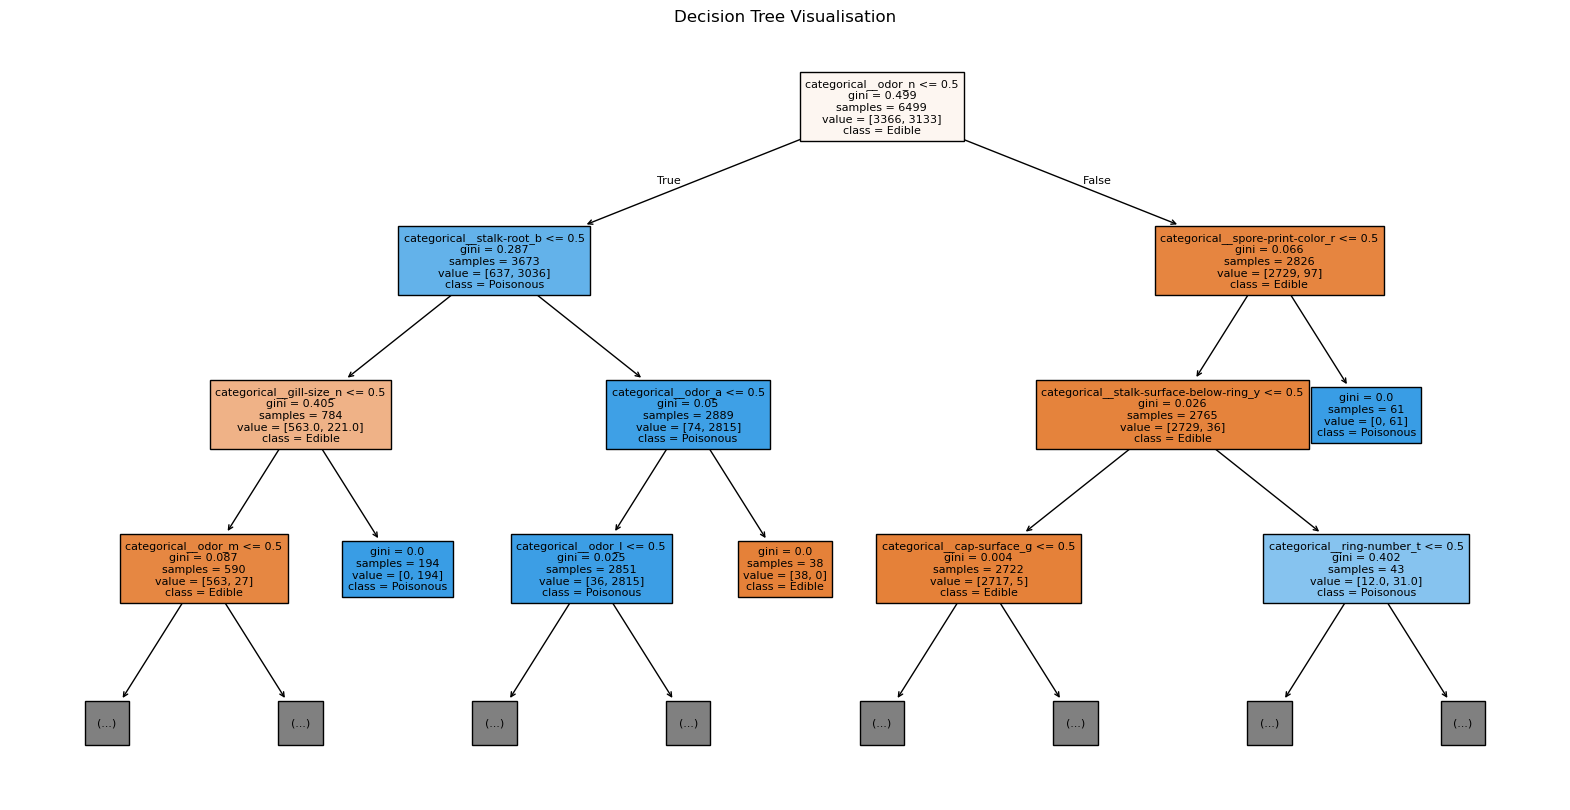

In [81]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=['Edible', 'Poisonous'],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualisation")
plt.xlabel("Features and decision rules")
plt.show()

### Observation

The tuning results show that different values of `max_depth` produce different classification accuracies. The value with the highest observed accuracy was selected for the final Decision Tree model. The visualisation shows how the selected tree uses feature-based decisions to classify mushrooms as edible or poisonous.

### Support Vector Machine (SVC)

Support Vector Machine (SVC) is used to classify mushrooms as edible or poisonous by finding a decision boundary between the two classes. The regularisation parameter `C` and kernel type are tuned to identify a suitable model configuration. The features are already scaled using the preprocessing pipeline from Section B2.

In [82]:
# Tune C and kernel
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Values of C and kernel to compare
C_values = [0.1, 1, 10]
kernel_values = ['linear', 'rbf']

svc_tuning_results = []

for C in C_values:
    for kernel in kernel_values:
        
        svc_model_temp = SVC(
            C=C,
            kernel=kernel,
            random_state=42
        )
        
        # Train the model
        svc_model_temp.fit(
            X_train_processed,
            y_train
        )
        
        # Generate predictions
        y_pred_svc_temp = svc_model_temp.predict(
            X_test_processed
        )
        
        # Calculate accuracy
        accuracy = accuracy_score(
            y_test,
            y_pred_svc_temp
        )
        
        svc_tuning_results.append({
            'C': C,
            'Kernel': kernel,
            'Accuracy': accuracy
        })

svc_tuning_df = pd.DataFrame(svc_tuning_results)

svc_tuning_df

,C,Kernel,Accuracy
0,0.1,linear,0.998769
1,0.1,rbf,0.996308
2,1.0,linear,1.000000
3,1.0,rbf,1.000000
4,10.0,linear,1.000000
5,10.0,rbf,1.000000


### Selecting the SVC Configuration

The combination of `C` and kernel with the highest observed accuracy is selected for the final Support Vector Machine model.

In [83]:
best_svc = svc_tuning_df.loc[
    svc_tuning_df['Accuracy'].idxmax()
]

print("Selected C:", best_svc['C'])
print("Selected kernel:", best_svc['Kernel'])

Selected C: 1.0
Selected kernel: linear


### Final SVC Model

The final Support Vector Machine is trained using the selected `C` value and kernel. The model is then used to generate predictions on the test dataset.

In [84]:
# Train the final SVC model
svc_model = SVC(
    C=best_svc['C'],
    kernel=best_svc['Kernel'],
    probability=True,
    random_state=42
)

svc_model.fit(
    X_train_processed,
    y_train
)

# Generate predictions
y_pred_svc = svc_model.predict(
    X_test_processed
)

print("Support Vector Machine predictions generated successfully.")

Support Vector Machine predictions generated successfully.


### Observation

The tuning results show that the choice of `C` and kernel affects SVC classification accuracy. The combination with the highest observed accuracy was selected for the final SVC model. The features were scaled during preprocessing before being provided to the SVC model.

## D2 — Evaluation

The five classification algorithms are evaluated on the unseen test dataset. Accuracy and weighted F1-score are calculated for each model, and confusion matrices are used to examine correct and incorrect predictions for the edible and poisonous classes.

### Evaluation Metrics

Accuracy measures the proportion of test samples that are classified correctly. Weighted F1-score combines precision and recall while taking the number of samples in each class into account.

In [85]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

# Store predictions from all five algorithms
models_predictions = {
    'Logistic Regression': y_pred_lr,
    'K-Nearest Neighbors': y_pred_knn,
    'Gaussian Naive Bayes': y_pred_nb,
    'Decision Tree': y_pred_dt,
    'Support Vector Machine': y_pred_svc
}

results = []

for model_name, predictions in models_predictions.items():

    # Accuracy
    accuracy = accuracy_score(y_test, predictions)

    # Precision
    precision = precision_score(y_test, predictions)

    # Recall
    recall = recall_score(y_test, predictions)

    # Weighted F1-score
    weighted_f1 = f1_score(
        y_test,
        predictions,
        average='weighted'
    )

    # Probability scores for ROC-AUC
    if model_name == 'Logistic Regression':
        probabilities = logistic_model.predict_proba(X_test_processed)[:, 1]

    elif model_name == 'K-Nearest Neighbors':
        probabilities = knn_model.predict_proba(X_test_processed)[:, 1]

    elif model_name == 'Gaussian Naive Bayes':
        probabilities = nb_model.predict_proba(X_test_processed)[:, 1]

    elif model_name == 'Decision Tree':
        probabilities = dt_model.predict_proba(X_test_processed)[:, 1]
    elif model_name == 'Support Vector Machine':
        probabilities = svc_model.predict_proba(X_test_processed)[:, 1]

    # ROC-AUC
    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    results.append({
        'Algorithm': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Weighted F1': weighted_f1,
        'ROC-AUC': roc_auc
    })

# Create comparison table
results_df = pd.DataFrame(results)

results_df

,Algorithm,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Logistic Regression,0.998769,1.000000,0.997446,0.998769,1.000000
1,K-Nearest Neighbors,1.000000,1.000000,1.000000,1.000000,1.000000
2,Gaussian Naive Bayes,0.964923,0.934211,0.997446,0.964927,0.996881
3,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
4,Support Vector Machine,1.000000,1.000000,1.000000,1.000000,1.000000


### Confusion Matrices

A confusion matrix shows the number of correct and incorrect predictions made by each classification algorithm. It shows how the models classify the edible and poisonous mushroom classes.

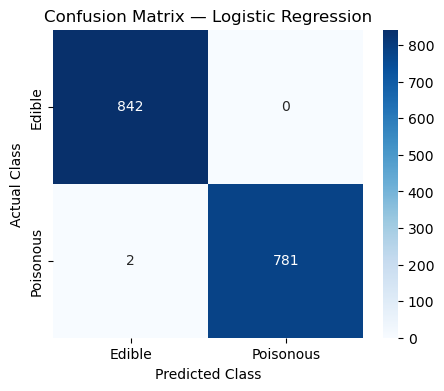

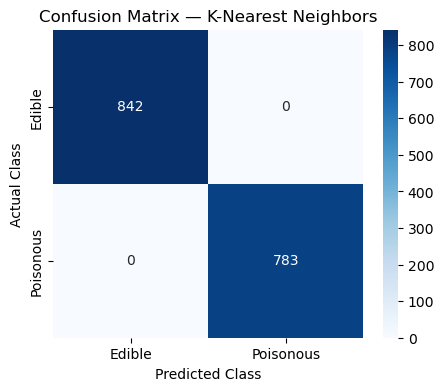

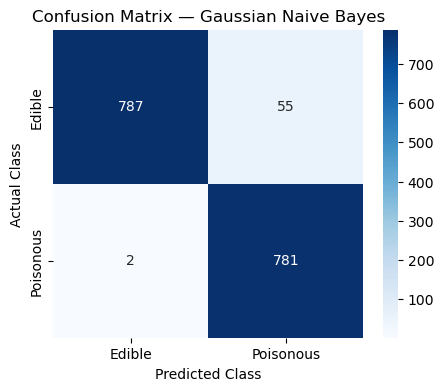

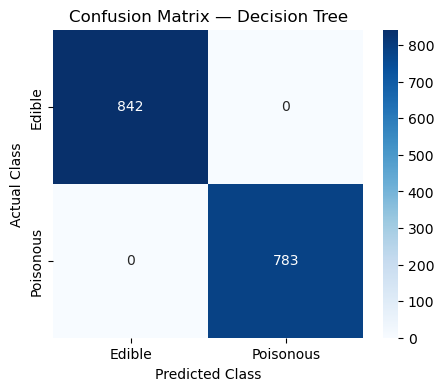

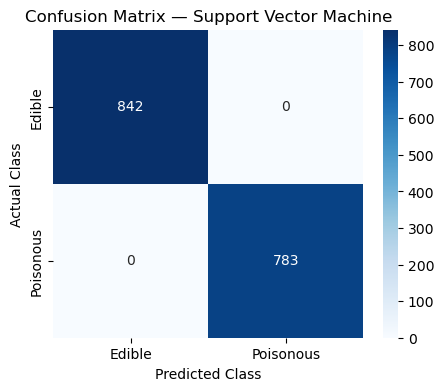

In [86]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, predictions in models_predictions.items():
    
    cm = confusion_matrix(y_test, predictions)
    
    plt.figure(figsize=(5, 4))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Edible', 'Poisonous'],
        yticklabels=['Edible', 'Poisonous']
    )
    
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.show()

### Preliminary Model Comparison

The performance of the five classification algorithms is summarised using accuracy and weighted F1-score. The comparison table provides an overall view of the models' performance on the test dataset.

In [87]:
# Display the final comparison table
results_df

,Algorithm,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Logistic Regression,0.998769,1.000000,0.997446,0.998769,1.000000
1,K-Nearest Neighbors,1.000000,1.000000,1.000000,1.000000,1.000000
2,Gaussian Naive Bayes,0.964923,0.934211,0.997446,0.964927,0.996881
3,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
4,Support Vector Machine,1.000000,1.000000,1.000000,1.000000,1.000000


### Classification Summary

All five required Part-A classification algorithms were successfully trained and generated predictions on the test dataset. Their performance was evaluated using **Accuracy, Precision, Recall, weighted F1-score, ROC-AUC, and Confusion Matrices**.

The preliminary comparison table summarises the classification performance of all five algorithms across these evaluation metrics.